In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level='WARNING', progress=False)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

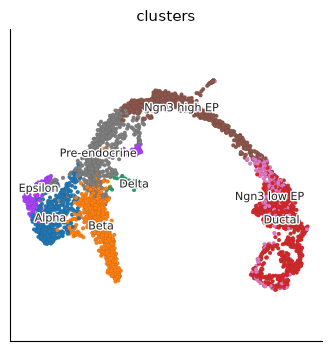

In [3]:
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    default_assay='RNA',
)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='clusters',
    legend_loc='on_data',
)

In [4]:
progenitors = ['Ductal']
terminal_cell_types = ['Alpha', 'Beta', 'Delta']

ds.cells.to_pandas_dataframe(
    ['clusters'],
    key='I'
)['clusters'].value_counts()

clusters
Ductal           733
Ngn3 high EP     624
Pre-endocrine    585
Beta             573
Alpha            454
Ngn3 low EP      233
Epsilon          141
Delta             70
Name: count, dtype: int64

In [5]:
pseudotime = ds.run_pseudotime_scoring(
    source_sink_key='clusters',
    sources=progenitors,
    sinks=terminal_cell_types,
    label='fate_pseudotime',
)

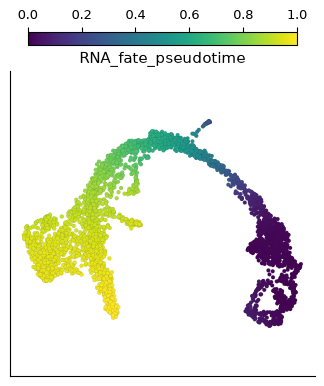

In [6]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=pseudotime.pseudotime_key,
    subset_by=pseudotime.validity_key,
)

In [7]:
fate = ds.run_fate_mapping(
    cell_key='I',
    subset_cell_key=pseudotime.validity_key,
    pseudotime_key=pseudotime.pseudotime_key,
    sink_key='clusters',
    sinks=terminal_cell_types,
)

In [8]:
pd.Series(
    dict(zip(fate.sink_labels, fate.fate_keys, strict=True)),
    name='cell metadata key',
)

Alpha    RNA_RNA_fate_pseudotime__valid_fate_Alpha
Beta      RNA_RNA_fate_pseudotime__valid_fate_Beta
Delta    RNA_RNA_fate_pseudotime__valid_fate_Delta
Name: cell metadata key, dtype: object

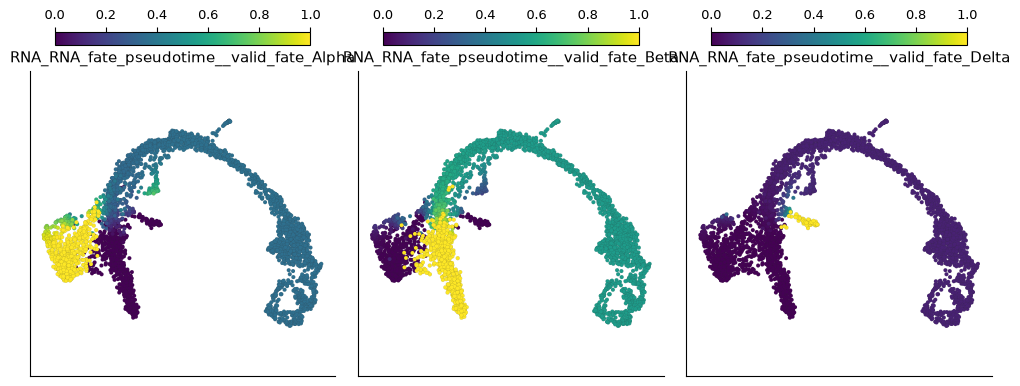

In [9]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=list(fate.fate_keys),
    subset_by=fate.validity_key,
    n_columns=3,
    sort_values=True,
)

In [10]:
valid_probabilities = fate.values[fate.valid]
simplex_error = float(
    np.max(np.abs(valid_probabilities.sum(axis=1) - 1.0))
)
assert simplex_error < 1e-5
simplex_error

1.1920928955078125e-07

In [11]:
selected_labels = ds.cells.fetch(
    fate.sink_key,
    key=fate.result_cell_key,
)
terminal_checks = []
for index, sink in enumerate(fate.sink_labels):
    rows = (selected_labels == sink) & fate.valid
    own_probability = fate.values[rows, index]
    other_probability = np.delete(fate.values[rows], index, axis=1)
    np.testing.assert_array_equal(
        own_probability,
        np.ones(own_probability.shape[0], dtype=np.float32),
    )
    assert np.count_nonzero(other_probability) == 0
    terminal_checks.append(
        {
            'sink': sink,
            'cells': int(rows.sum()),
            'minimum own probability': float(own_probability.min()),
            'maximum other probability': float(other_probability.max()),
        }
    )

pd.DataFrame(terminal_checks)

,sink,cells,minimum own probability,maximum other probability
0,Alpha,454,1.0,0.0
1,Beta,573,1.0,0.0
2,Delta,70,1.0,0.0
